## E. Model Predictions

## Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

### Read Data

In [3]:
df = pd.read_csv( 'df_model' )

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  28356 non-null  object 
 1   track_popularity          28356 non-null  int64  
 2   playlist_genre            28356 non-null  object 
 3   danceability              28356 non-null  float64
 4   track_album_release_date  28356 non-null  object 
 5   tempo                     28356 non-null  float64
 6   energy                    28356 non-null  float64
 7   popularity_category       28356 non-null  object 
 8   release_year              28356 non-null  int64  
 9   bin_year                  28356 non-null  object 
 10  log_tempo                 28356 non-null  float64
 11  target                    28356 non-null  int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 2.6+ MB


Fitting model with all inputs and linear additive features.

In [6]:
model_all = smf.logit(formula='target ~ danceability + log_tempo + energy + playlist_genre', data=df).fit()

Optimization terminated successfully.
         Current function value: 0.632931
         Iterations 5


In [7]:
model_all.params

Intercept                 -2.712370
playlist_genre[T.latin]    1.063312
playlist_genre[T.pop]      1.486804
playlist_genre[T.r&b]      0.686156
playlist_genre[T.rap]      1.072806
playlist_genre[T.rock]     1.254084
danceability               0.753882
log_tempo                  0.244140
energy                    -0.637997
dtype: float64

In [9]:
model_all.pvalues < 0.05

Intercept                  True
playlist_genre[T.latin]    True
playlist_genre[T.pop]      True
playlist_genre[T.r&b]      True
playlist_genre[T.rap]      True
playlist_genre[T.rock]     True
danceability               True
log_tempo                  True
energy                     True
dtype: bool

Fitting the best model in training set. 

In [11]:
model_interactions_cat_cont = smf.logit(formula='target ~ danceability + log_tempo + energy + playlist_genre + danceability:playlist_genre + log_tempo:playlist_genre + energy:playlist_genre',
                                       data=df).fit()

Optimization terminated successfully.
         Current function value: 0.630261
         Iterations 6


In [12]:
model_interactions_cat_cont.params

Intercept                               0.240536
playlist_genre[T.latin]                -1.966398
playlist_genre[T.pop]                  -0.152507
playlist_genre[T.r&b]                  -1.601611
playlist_genre[T.rap]                  -3.685979
playlist_genre[T.rock]                 -1.667186
danceability                           -1.028675
danceability:playlist_genre[T.latin]    1.749476
danceability:playlist_genre[T.pop]      2.137692
danceability:playlist_genre[T.r&b]      0.869397
danceability:playlist_genre[T.rap]      3.201196
danceability:playlist_genre[T.rock]     1.640296
log_tempo                              -0.101366
log_tempo:playlist_genre[T.latin]       0.336959
log_tempo:playlist_genre[T.pop]        -0.073946
log_tempo:playlist_genre[T.r&b]         0.399556
log_tempo:playlist_genre[T.rap]         0.564988
log_tempo:playlist_genre[T.rock]        0.304928
energy                                 -0.773858
energy:playlist_genre[T.latin]          0.334966
energy:playlist_genr

In [15]:
model_interactions_cat_cont.pvalues < 0.05

Intercept                               False
playlist_genre[T.latin]                 False
playlist_genre[T.pop]                   False
playlist_genre[T.r&b]                   False
playlist_genre[T.rap]                    True
playlist_genre[T.rock]                  False
danceability                             True
danceability:playlist_genre[T.latin]     True
danceability:playlist_genre[T.pop]       True
danceability:playlist_genre[T.r&b]       True
danceability:playlist_genre[T.rap]       True
danceability:playlist_genre[T.rock]      True
log_tempo                               False
log_tempo:playlist_genre[T.latin]       False
log_tempo:playlist_genre[T.pop]         False
log_tempo:playlist_genre[T.r&b]         False
log_tempo:playlist_genre[T.rap]         False
log_tempo:playlist_genre[T.rock]        False
energy                                   True
energy:playlist_genre[T.latin]          False
energy:playlist_genre[T.pop]             True
energy:playlist_genre[T.r&b]      

Prediction Grid

In [22]:
input_grid = pd.DataFrame([ (danceability, energy, log_tempo, playlist_genre) for danceability in np.linspace(df.danceability.min(), df.danceability.max(), num=101)
                                                                   for energy in np.linspace(df.energy.min(), df.energy.max(), num=5)
                                                                   for log_tempo in [df.log_tempo.mean()]
                                                                   for playlist_genre in df.playlist_genre.unique() ],
                         columns=['danceability', 'energy', 'log_tempo', 'playlist_genre'])

In [23]:
input_grid.shape

(3030, 4)

In [24]:
input_grid.nunique()

danceability      101
energy              5
log_tempo           1
playlist_genre      6
dtype: int64

In [25]:
input_grid.playlist_genre.value_counts()

playlist_genre
pop      505
rap      505
rock     505
latin    505
r&b      505
edm      505
Name: count, dtype: int64

In [26]:
input_grid

,danceability,energy,log_tempo,playlist_genre
0,0.000,0.000175,4.779362,pop
1,0.000,0.000175,4.779362,rap
2,0.000,0.000175,4.779362,rock
3,0.000,0.000175,4.779362,latin
4,0.000,0.000175,4.779362,r&b
...,...,...,...,...
3025,0.983,1.000000,4.779362,rap
3026,0.983,1.000000,4.779362,rock
3027,0.983,1.000000,4.779362,latin
3028,0.983,1.000000,4.779362,r&b


In [27]:
dfviz = input_grid.copy()

In [28]:
dfviz['pred_probability_all'] = model_all.predict( input_grid )

In [29]:
dfviz

,danceability,energy,log_tempo,playlist_genre,pred_probability_all
0,0.000,0.000175,4.779362,pop,0.485294
1,0.000,0.000175,4.779362,rap,0.383944
2,0.000,0.000175,4.779362,rock,0.427622
3,0.000,0.000175,4.779362,latin,0.381701
4,0.000,0.000175,4.779362,r&b,0.297446
...,...,...,...,...,...
3025,0.983,1.000000,4.779362,rap,0.408623
3026,0.983,1.000000,4.779362,rock,0.453043
3027,0.983,1.000000,4.779362,latin,0.406331
3028,0.983,1.000000,4.779362,r&b,0.319448


In [30]:
dfviz['pred_probability_int'] = model_interactions_cat_cont.predict( input_grid )

In [31]:
dfviz

,danceability,energy,log_tempo,playlist_genre,pred_probability_all,pred_probability_int
0,0.000,0.000175,4.779362,pop,0.485294,0.320855
1,0.000,0.000175,4.779362,rap,0.383944,0.226215
2,0.000,0.000175,4.779362,rock,0.427622,0.388455
3,0.000,0.000175,4.779362,latin,0.381701,0.354354
4,0.000,0.000175,4.779362,r&b,0.297446,0.515964
...,...,...,...,...,...,...
3025,0.983,1.000000,4.779362,rap,0.408623,0.464297
3026,0.983,1.000000,4.779362,rock,0.453043,0.458864
3027,0.983,1.000000,4.779362,latin,0.406331,0.418186
3028,0.983,1.000000,4.779362,r&b,0.319448,0.219898


C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


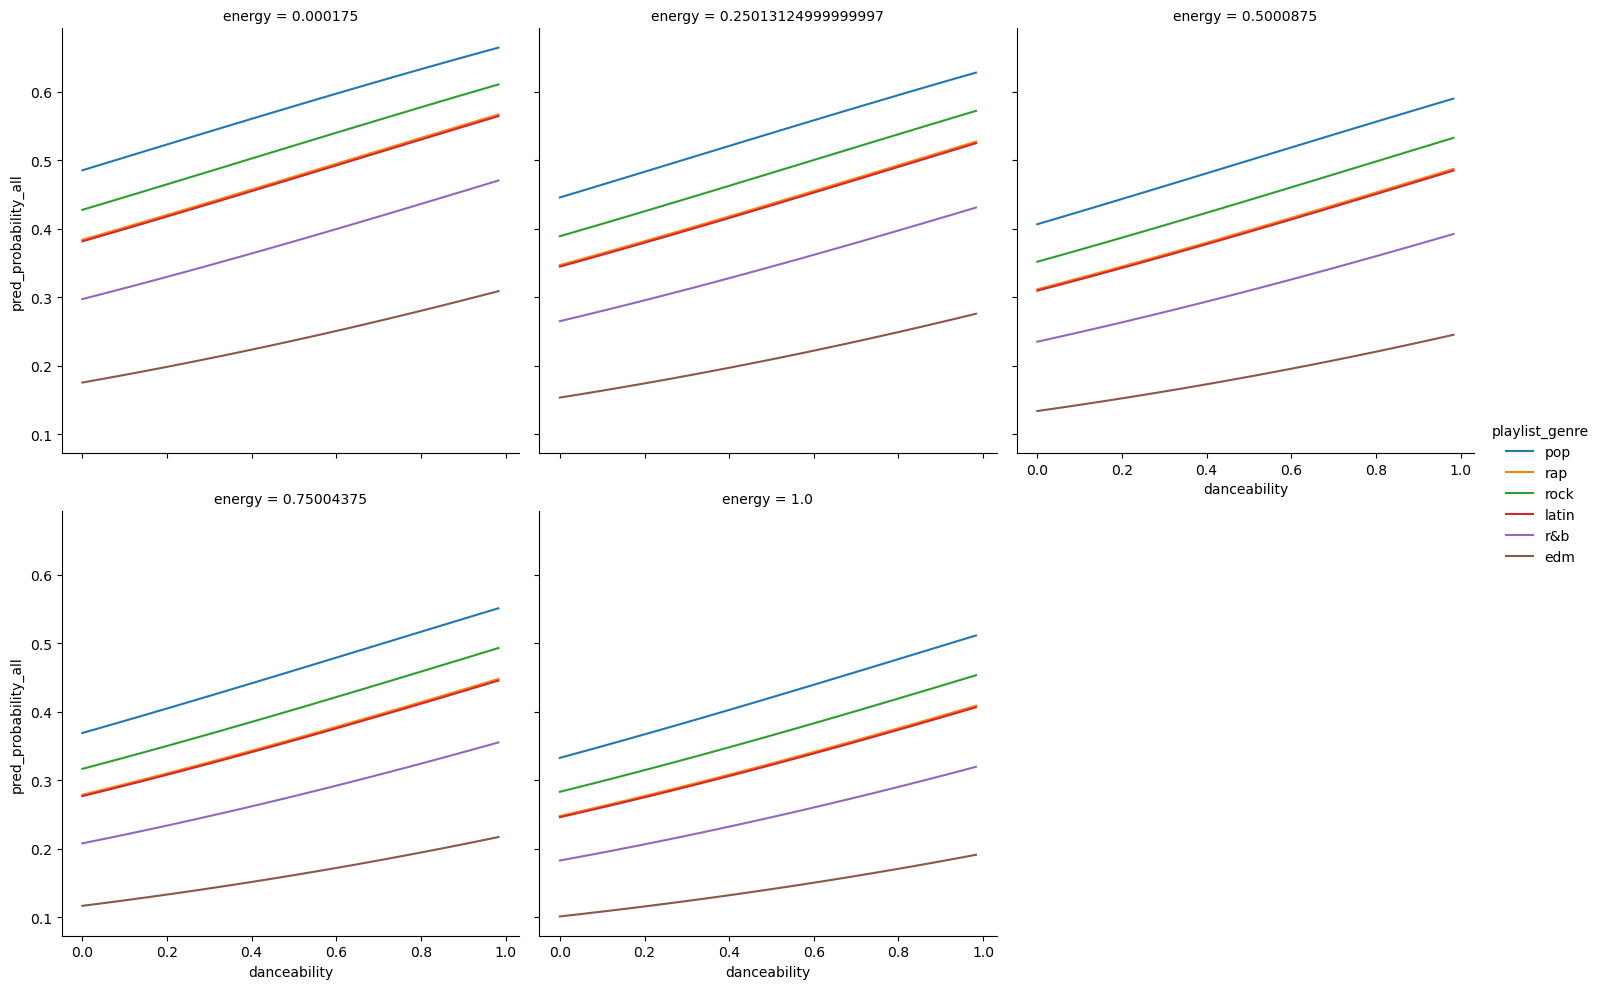

In [33]:
sns.relplot( data = dfviz, x='danceability', y='pred_probability_all', hue='playlist_genre', col='energy',
            col_wrap=3, kind='line', estimator=None, units='playlist_genre')

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


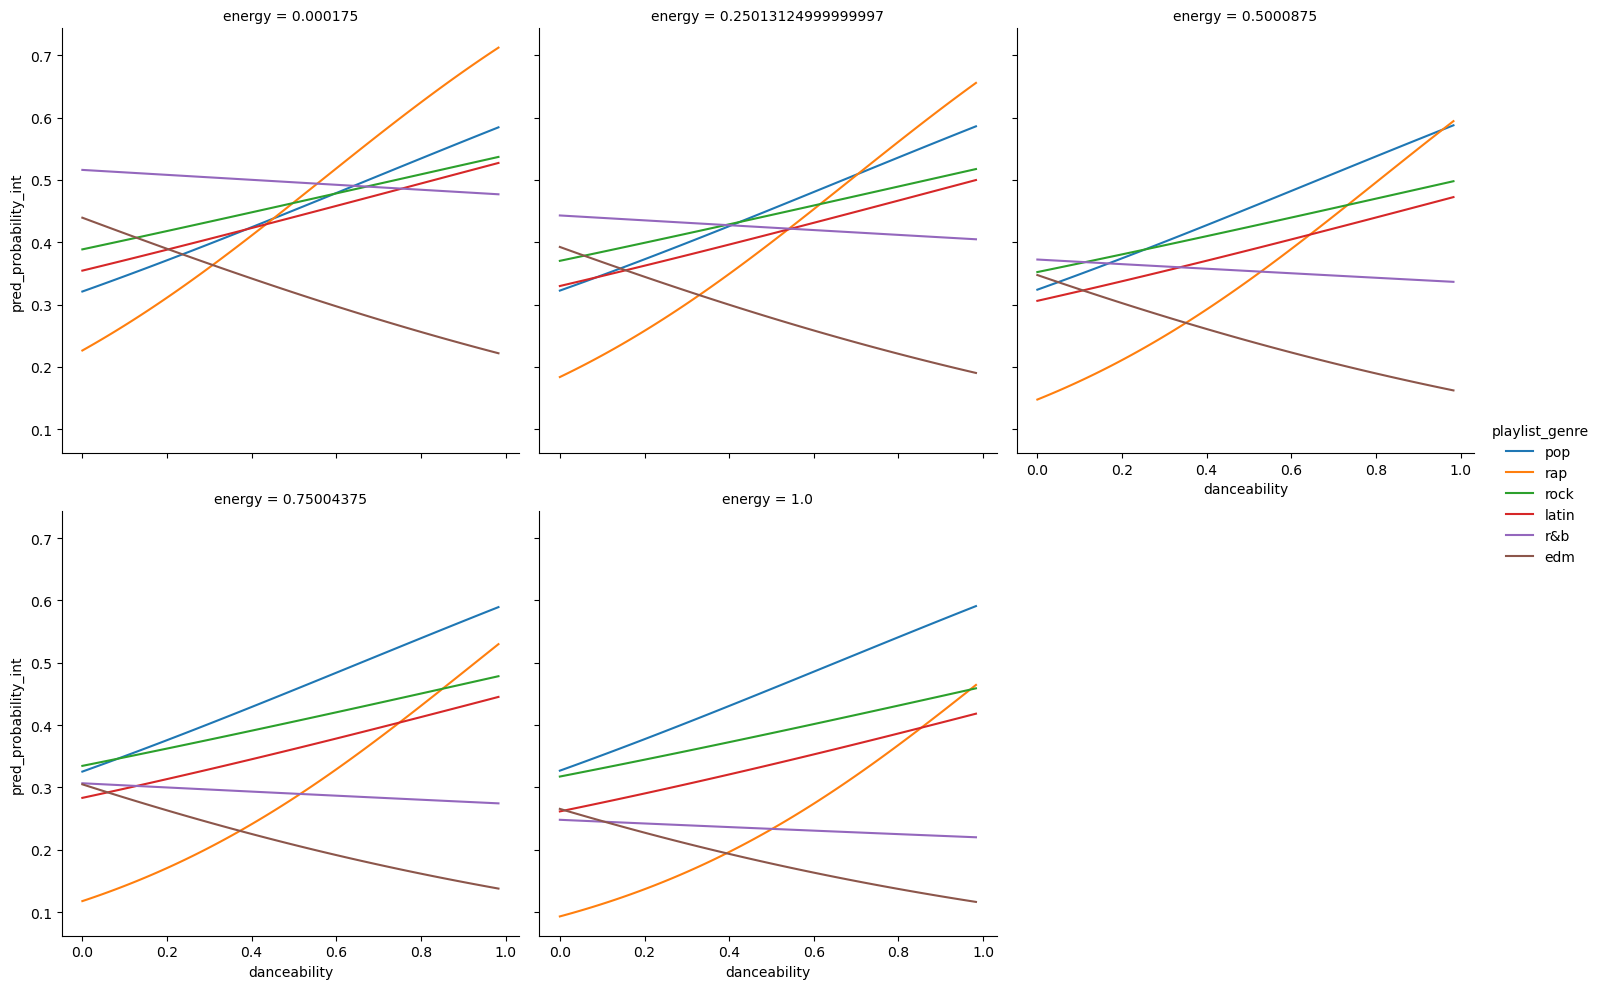

In [34]:
sns.relplot( data = dfviz, x='danceability', y='pred_probability_int', hue='playlist_genre', col='energy',
            col_wrap=3, kind='line', estimator=None, units='playlist_genre')

plt.show()

The first plot demonstrates clear, positive, and consistent relationships between danceability and predicted popularity across all genres and energy levels. The lines are well-separated by genre, with pop and rap consistently showing the highest predicted probabilities, while EDM remains the lowest, regardless of energy. This indicates that the model is more stable, interpretable, and likely better calibrated.

In contrast, the second plot, the relationships between danceability and predicted popularity are less consistent across genres and energy levels. Some lines even show negative slopes (e.g., EDM), suggesting instability or possibly overfitting in the interaction model. The varied directions and slopes imply that the interaction terms introduced may not generalize well or could be distorting the influence of key features.

Overall, the first model (pred_probability_all) appears to outperform the interaction-based model in terms of consistency, interpretability, and predictive structure, suggesting that a well-specified additive model may be more effective for this task than one overloaded with interaction terms.

